DataSet Link :https://www.kaggle.com/datasets/yug201/delhi-5-minute-electricity-demand-for-forecasting

Import necessary Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

Reading the Data

In [ ]:
#Exception Handling
try:
    df_raw = pd.read_csv("/content/powerdemand_5min_2021_to_2024_with weather.csv")

except FileNotFoundError:
    print("Error: File 'powerdemand_5min_2021_to_2024_with weather.csv' not found. Please check the file path.")  # More specific error message
except Exception as e:
    print(f"An error occurred: {e}")


Data Understanding

In [ ]:
display(df_raw.head())
print(df_raw.shape)
print(df_raw.info())
print(df_raw.describe())

# 4. Identify the target variable
# The target variable is 'Power demand'.
print("Target Variable: 'Power demand'")

,Unnamed: 0,datetime,Power demand,temp,dwpt,rhum,wdir,wspd,pres,year,month,day,hour,minute,moving_avg_3
0,0,2021-01-01 00:30:00,2014.00,8.0,6.9,93.0,0.0,0.0,1017.0,2021,1,1,0,30,NaN
1,1,2021-01-01 00:35:00,2005.63,8.0,6.9,93.0,0.0,0.0,1017.0,2021,1,1,0,35,NaN
2,2,2021-01-01 00:40:00,1977.60,8.0,6.9,93.0,0.0,0.0,1017.0,2021,1,1,0,40,1999.076667
3,3,2021-01-01 00:45:00,1976.44,8.0,6.9,93.0,0.0,0.0,1017.0,2021,1,1,0,45,1986.556667
4,4,2021-01-01 00:50:00,1954.37,8.0,6.9,93.0,0.0,0.0,1017.0,2021,1,1,0,50,1969.470000


(393440, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 393440 entries, 0 to 393439
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Unnamed: 0    393440 non-null  int64  
 1   datetime      393440 non-null  object 
 2   Power demand  393440 non-null  float64
 3   temp          393440 non-null  float64
 4   dwpt          393440 non-null  float64
 5   rhum          393440 non-null  float64
 6   wdir          392900 non-null  float64
 7   wspd          393440 non-null  float64
 8   pres          393440 non-null  float64
 9   year          393440 non-null  int64  
 10  month         393440 non-null  int64  
 11  day           393440 non-null  int64  
 12  hour          393440 non-null  int64  
 13  minute        393440 non-null  int64  
 14  moving_avg_3  393438 non-null  float64
dtypes: float64(8), int64(6), object(1)
memory usage: 45.0+ MB
None
          Unnamed: 0   Power demand           temp          

In [ ]:
# Convert 'datetime' column to datetime objects
df_raw['datetime'] = pd.to_datetime(df_raw['datetime'])

#Missing Values
# 1. Examine data types and missing values
print("Data Types:")
print(df_raw.dtypes)
print("\nMissing Values:")
print(df_raw.isnull().sum())


Data Types:
Unnamed: 0               int64
datetime        datetime64[ns]
Power demand           float64
temp                   float64
dwpt                   float64
rhum                   float64
wdir                   float64
wspd                   float64
pres                   float64
year                     int64
month                    int64
day                      int64
hour                     int64
minute                   int64
moving_avg_3           float64
dtype: object

Missing Values:
Unnamed: 0        0
datetime          0
Power demand      0
temp              0
dwpt              0
rhum              0
wdir            540
wspd              0
pres              0
year              0
month             0
day               0
hour              0
minute            0
moving_avg_3      2
dtype: int64


Data Visualisation

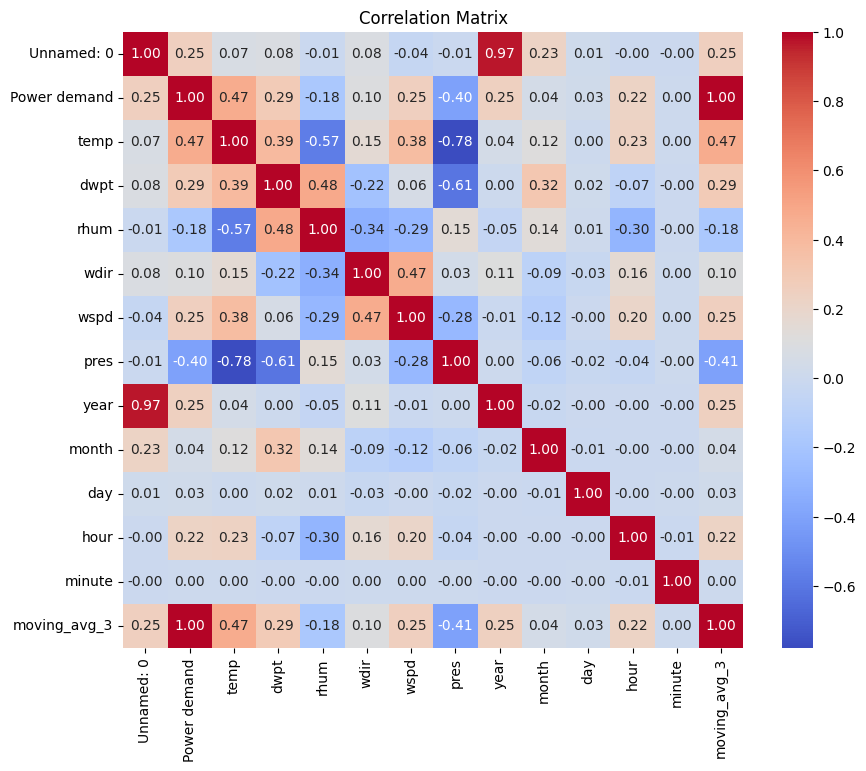

In [ ]:
# 3. Analyze relationships between features
# Exclude the 'datetime' column from correlation calculation
plt.figure(figsize=(10, 8))
correlation_matrix = df_raw.drop(columns=['datetime']).corr()  # Exclude 'datetime'

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()


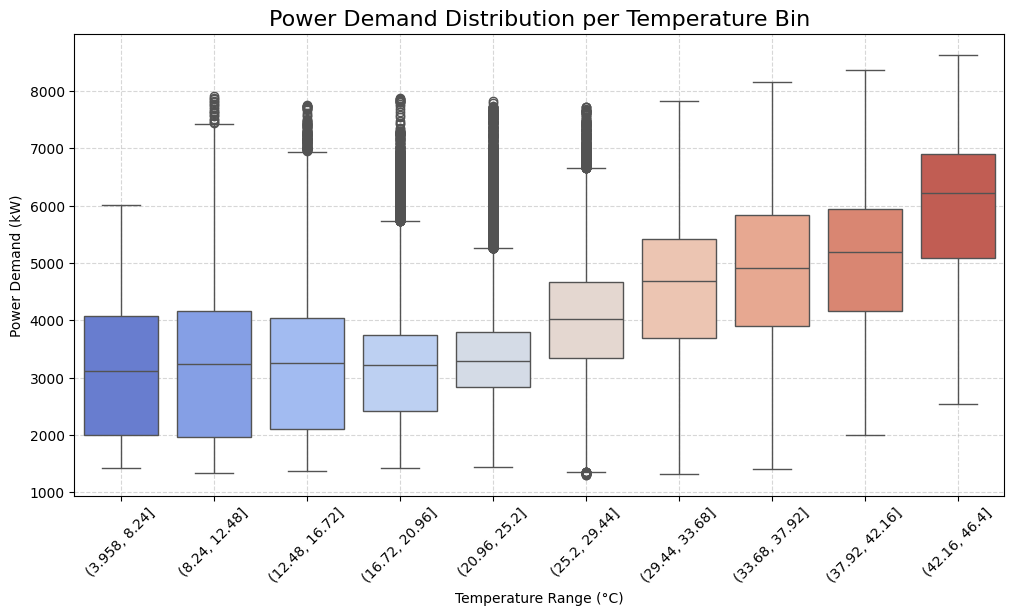

In [ ]:
# Bucket temperature into bins
df_raw['temp_bin'] = pd.cut(df_raw['temp'], bins=10)

plt.figure(figsize=(12, 6))
sns.boxplot(x='temp_bin', y='Power demand', data=df_raw, hue='temp_bin', palette='coolwarm', legend=False)
plt.xticks(rotation=45)
plt.title('Power Demand Distribution per Temperature Bin', fontsize=16)
plt.xlabel('Temperature Range (°C)')
plt.ylabel('Power Demand (kW)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()




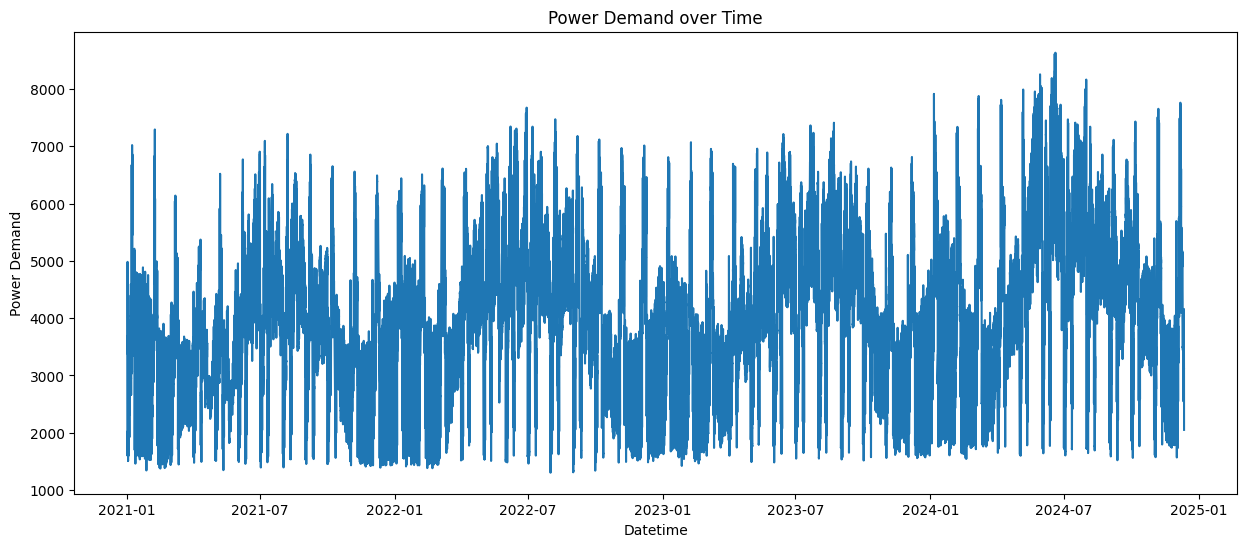

In [ ]:
# 5. Time series analysis (initial)
plt.figure(figsize=(15, 6))
plt.plot(df_raw['datetime'], df_raw['Power demand'])
plt.xlabel('Datetime')
plt.ylabel('Power Demand')
plt.title('Power Demand over Time')
plt.show()

In [ ]:
# 6. Summarize initial findings
print("Summary of Initial Findings:")
print("-" * 30)
print("Data Types:")
print("The 'datetime' column has been successfully converted to datetime objects. Other columns have appropriate data types for their respective information.")
print("\nMissing Values:")
print("The 'wdir' column has 540 missing values, and the 'moving_avg_3' column has 2 missing values.  The proportion of missing data is relatively small for both columns.")
print("Further investigation is needed to determine if these missing values are completely at random, missing at random, or not missing at random. Imputation or removal strategies will be considered based on the pattern of missingness.")

print("\nDistributions:")
print("The 'Power demand' distribution shows some right-skewness. Outliers may be present, which should be analyzed more thoroughly.")
print("The 'temp' column shows a distribution that is expected for temperature data. Further analysis of other numerical features will provide insights into their characteristics. ")

print("\nCorrelations:")
print("The heatmap revealed the correlation between different features.  There are some visible correlations, particularly between the 'Power demand' and other factors.  These relationships should be further examined. More detailed plots and statistical tests may be used to assess significance and strength of associations.")

print("\nTime Series Analysis (Initial):")
print("The time series plot of 'Power demand' suggests the presence of trends and potential seasonality. Closer inspection and decomposition will be required.")

Summary of Initial Findings:
------------------------------
Data Types:
The 'datetime' column has been successfully converted to datetime objects. Other columns have appropriate data types for their respective information.

Missing Values:
The 'wdir' column has 540 missing values, and the 'moving_avg_3' column has 2 missing values.  The proportion of missing data is relatively small for both columns.
Further investigation is needed to determine if these missing values are completely at random, missing at random, or not missing at random. Imputation or removal strategies will be considered based on the pattern of missingness.

Distributions:
The 'Power demand' distribution shows some right-skewness. Outliers may be present, which should be analyzed more thoroughly.
The 'temp' column shows a distribution that is expected for temperature data. Further analysis of other numerical features will provide insights into their characteristics. 

Correlations:
The heatmap revealed the correlation

Data Cleaning

In [ ]:
# Impute missing values in 'wdir' using the median, as it's less sensitive to outliers than the mean.
# The median is a good choice because wind direction might not follow a normal distribution.
df_cleaned = df_raw.copy()
df_cleaned['wdir'] = df_cleaned['wdir'].fillna(df_cleaned['wdir'].median())

# Impute missing values in 'moving_avg_3' using forward fill. Given the small number of missing values, forward fill is a reasonable approach.
df_cleaned['moving_avg_3'] = df_cleaned['moving_avg_3'].ffill()

# Outlier detection and treatment for 'Power demand'
# Winsorize the 'Power demand' column to handle outliers. This method limits extreme values to a certain percentile, preserving most of the data while mitigating the influence of outliers.
from scipy.stats.mstats import winsorize
df_cleaned['Power demand'] = winsorize(df_cleaned['Power demand'], limits=[0.01, 0.01]) # Winsorize the top and bottom 1%

# Check for and remove duplicate rows
num_duplicates = df_cleaned.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")
if num_duplicates > 0:
    df_cleaned = df_cleaned.drop_duplicates()

# Ensure all columns have the correct data types
# 'datetime' column is already datetime64[ns]


display(df_cleaned.head())
print(df_cleaned.info())


Number of duplicate rows: 0


,Unnamed: 0,datetime,Power demand,temp,dwpt,rhum,wdir,wspd,pres,year,month,day,hour,minute,moving_avg_3,temp_bin
0,0,2021-01-01 00:30:00,2014.00,8.0,6.9,93.0,0.0,0.0,1017.0,2021,1,1,0,30,NaN,"(3.958, 8.24]"
1,1,2021-01-01 00:35:00,2005.63,8.0,6.9,93.0,0.0,0.0,1017.0,2021,1,1,0,35,NaN,"(3.958, 8.24]"
2,2,2021-01-01 00:40:00,1977.60,8.0,6.9,93.0,0.0,0.0,1017.0,2021,1,1,0,40,1999.076667,"(3.958, 8.24]"
3,3,2021-01-01 00:45:00,1976.44,8.0,6.9,93.0,0.0,0.0,1017.0,2021,1,1,0,45,1986.556667,"(3.958, 8.24]"
4,4,2021-01-01 00:50:00,1954.37,8.0,6.9,93.0,0.0,0.0,1017.0,2021,1,1,0,50,1969.470000,"(3.958, 8.24]"


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 393440 entries, 0 to 393439
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Unnamed: 0    393440 non-null  int64         
 1   datetime      393440 non-null  datetime64[ns]
 2   Power demand  393440 non-null  float64       
 3   temp          393440 non-null  float64       
 4   dwpt          393440 non-null  float64       
 5   rhum          393440 non-null  float64       
 6   wdir          393440 non-null  float64       
 7   wspd          393440 non-null  float64       
 8   pres          393440 non-null  float64       
 9   year          393440 non-null  int64         
 10  month         393440 non-null  int64         
 11  day           393440 non-null  int64         
 12  hour          393440 non-null  int64         
 13  minute        393440 non-null  int64         
 14  moving_avg_3  393438 non-null  float64       
 15  temp_bin      393

Data Processing

In [ ]:
# Feature Engineering
df_cleaned['day_of_week'] = df_cleaned['datetime'].dt.dayofweek
df_cleaned['hour_of_day'] = df_cleaned['datetime'].dt.hour
df_cleaned['month'] = df_cleaned['datetime'].dt.month
df_cleaned['hour_sin'] = np.sin(2 * np.pi * df_cleaned['hour_of_day'] / 24)
df_cleaned['hour_cos'] = np.cos(2 * np.pi * df_cleaned['hour_of_day'] / 24)
df_cleaned['day_sin'] = np.sin(2 * np.pi * df_cleaned['day_of_week'] / 7)
df_cleaned['day_cos'] = np.cos(2 * np.pi * df_cleaned['day_of_week'] / 7)

# Drop the 'temp_bin' column before scaling and model training
df_cleaned = df_cleaned.drop(columns=['temp_bin'])
df_cleaned


,Unnamed: 0,datetime,Power demand,temp,dwpt,rhum,wdir,wspd,pres,year,...,day,hour,minute,moving_avg_3,day_of_week,hour_of_day,hour_sin,hour_cos,day_sin,day_cos
0,0,2021-01-01 00:30:00,2014.00,8.0,6.9,93.0,0.0,0.0,1017.0,2021,...,1,0,30,NaN,4,0,0.0,1.0,-0.433884,-0.900969
1,1,2021-01-01 00:35:00,2005.63,8.0,6.9,93.0,0.0,0.0,1017.0,2021,...,1,0,35,NaN,4,0,0.0,1.0,-0.433884,-0.900969
2,2,2021-01-01 00:40:00,1977.60,8.0,6.9,93.0,0.0,0.0,1017.0,2021,...,1,0,40,1999.076667,4,0,0.0,1.0,-0.433884,-0.900969
3,3,2021-01-01 00:45:00,1976.44,8.0,6.9,93.0,0.0,0.0,1017.0,2021,...,1,0,45,1986.556667,4,0,0.0,1.0,-0.433884,-0.900969
4,4,2021-01-01 00:50:00,1954.37,8.0,6.9,93.0,0.0,0.0,1017.0,2021,...,1,0,50,1969.470000,4,0,0.0,1.0,-0.433884,-0.900969
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
393435,393435,2024-12-12 00:10:00,2146.84,12.3,6.8,69.0,269.0,1.8,1019.4,2024,...,12,0,10,2174.893333,3,0,0.0,1.0,0.433884,-0.900969
393436,393436,2024-12-12 00:15:00,2116.66,12.3,6.8,69.0,269.0,1.8,1019.4,2024,...,12,0,15,2139.416667,3,0,0.0,1.0,0.433884,-0.900969
393437,393437,2024-12-12 00:20:00,2082.77,12.3,6.8,69.0,269.0,1.8,1019.4,2024,...,12,0,20,2115.423333,3,0,0.0,1.0,0.433884,-0.900969
393438,393438,2024-12-12 00:25:00,2059.17,12.3,6.8,69.0,269.0,1.8,1019.4,2024,...,12,0,25,2086.200000,3,0,0.0,1.0,0.433884,-0.900969


In [ ]:
# Scaling Numerical Features
numerical_cols = ['Power demand', 'temp', 'dwpt', 'rhum', 'wdir', 'wspd', 'pres', 'moving_avg_3']
scaler = RobustScaler()
df_scaled = df_cleaned.copy()
df_scaled[numerical_cols] = scaler.fit_transform(df_cleaned[numerical_cols])

display(df_scaled.head())



,Unnamed: 0,datetime,Power demand,temp,dwpt,rhum,wdir,wspd,pres,year,...,day,hour,minute,moving_avg_3,day_of_week,hour_of_day,hour_sin,hour_cos,day_sin,day_cos
0,0,2021-01-01 00:30:00,-1.012673,-1.727273,-0.62963,0.65,-0.727273,-1.310345,0.666667,2021,...,1,0,30,NaN,4,0,0.0,1.0,-0.433884,-0.900969
1,1,2021-01-01 00:35:00,-1.017334,-1.727273,-0.62963,0.65,-0.727273,-1.310345,0.666667,2021,...,1,0,35,NaN,4,0,0.0,1.0,-0.433884,-0.900969
2,2,2021-01-01 00:40:00,-1.032945,-1.727273,-0.62963,0.65,-0.727273,-1.310345,0.666667,2021,...,1,0,40,-1.021519,4,0,0.0,1.0,-0.433884,-0.900969
3,3,2021-01-01 00:45:00,-1.033591,-1.727273,-0.62963,0.65,-0.727273,-1.310345,0.666667,2021,...,1,0,45,-1.028498,4,0,0.0,1.0,-0.433884,-0.900969
4,4,2021-01-01 00:50:00,-1.045882,-1.727273,-0.62963,0.65,-0.727273,-1.310345,0.666667,2021,...,1,0,50,-1.038022,4,0,0.0,1.0,-0.433884,-0.900969


In [ ]:
# Define features (X) and target (y)
X = df_scaled.drop(columns=['Power demand', 'datetime'])
y = df_scaled['Power demand']

# Split data into temporary training and combined validation/testing sets
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=df_scaled['hour_of_day']
)

# Get the indices from the temporary training set
temp_indices = X_temp.index

# Use the indices to select the corresponding 'hour_of_day' values for stratification
hour_of_day_temp = df_scaled.loc[temp_indices, 'hour_of_day']

# Split combined validation/testing sets into separate validation and testing sets
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=hour_of_day_temp
)

print(X_train.shape, X_val.shape, X_test.shape, y_train.shape, y_val.shape, y_test.shape)



(157376, 19) (157376, 19) (78688, 19) (157376,) (157376,) (78688,)


In [ ]:
# Define features (X) and target (y)
X = df_scaled.drop(columns=['Power demand', 'datetime'])
y = df_scaled['Power demand']

# Split data into temporary training and combined validation/testing sets
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=df_scaled['hour_of_day']
)

# Get the indices from the temporary training set
temp_indices = X_temp.index

# Use the indices to select the corresponding 'hour_of_day' values for stratification
hour_of_day_temp = df_scaled.loc[temp_indices, 'hour_of_day']

# Split combined validation/testing sets into separate validation and testing sets
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=hour_of_day_temp
)

print(X_train.shape, X_val.shape, X_test.shape, y_train.shape, y_val.shape, y_test.shape)

(157376, 19) (157376, 19) (78688, 19) (157376,) (157376,) (78688,)


In [ ]:
from sklearn.impute import SimpleImputer
# Initialize the imputer with your chosen strategy
imputer = SimpleImputer(strategy='median') # Or another strategy like 'mean'


# Define features (X) and target (y)
X = df_scaled.drop(columns=['Power demand', 'datetime'])
y = df_scaled['Power demand']

# Split data into temporary training and combined validation/testing sets
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=df_scaled['hour_of_day']
)

# Get the indices from the temporary training set
temp_indices = X_temp.index

# Use the indices to select the corresponding 'hour_of_day' values for stratification
hour_of_day_temp = df_scaled.loc[temp_indices, 'hour_of_day']

# Split combined validation/testing sets into separate validation and testing sets
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=hour_of_day_temp
)

# Fit the imputer on the training data and transform both training and test data
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test) # Use the same imputer to transform X_test


# Initialize and train the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Reshape y_pred into a 2D array
y_pred_2d = y_pred.reshape(-1, 1)  # Reshape before inverse_transform

# Inverse transform only the 'Power demand' column (first column)
y_pred_original = scaler.inverse_transform(np.concatenate([y_pred_2d, np.zeros((len(y_pred_2d), len(numerical_cols) -1))], axis=1))[:, 0]

y_test_original = scaler.inverse_transform(np.concatenate([y_test.values.reshape(-1, 1), np.zeros((len(y_test), len(numerical_cols) - 1))], axis=1))[:, 0]

# Create a DataFrame for comparison
comparison_df = pd.DataFrame({'Actual': y_test_original, 'Predicted': y_pred_original})
print(comparison_df)


# Evaluate the model
mse = mean_squared_error(y_test_original, y_pred_original)
rmse= np.sqrt(mse)
r2 = r2_score(y_test_original, y_pred_original)

print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"R-squared: {r2}")


        Actual    Predicted
0      5693.96  5665.271382
1      2976.91  2985.292537
2      4028.20  4026.412667
3      4727.87  4737.377896
4      3396.00  3420.744351
...        ...          ...
78683  5082.79  5083.597111
78684  2914.62  2926.717920
78685  5589.37  5481.522994
78686  3954.66  3962.965017
78687  4521.63  4515.314966

[78688 rows x 2 columns]
Mean Squared Error: 5072.288478191204
Root Mean Squared Error: 71.22000054894134
R-squared: 0.9969540017907995


Random Forest Regressor

In [ ]:
# Initialize and train the Random Forest Regressor model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)  # You can tune hyperparameters
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Inverse transform for Random Forest predictions
y_pred_rf_2d = y_pred_rf.reshape(-1, 1)
y_pred_rf_original = scaler.inverse_transform(
    np.concatenate([y_pred_rf_2d, np.zeros((len(y_pred_rf_2d), len(numerical_cols) - 1))], axis=1)
)[:, 0]

# Evaluate Random Forest model
mse_rf = mean_squared_error(y_test_original, y_pred_rf_original)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test_original, y_pred_rf_original)

print(f"\nRandom Forest Regression:")
print(f"Mean Squared Error: {mse_rf}")
print(f"Root Mean Squared Error: {rmse_rf}")
print(f"R-squared: {r2_rf}")

# Create a comparison table for Random Forest
comparison_df_rf = pd.DataFrame({'Actual': y_test_original, 'Predicted_RF': y_pred_rf_original})
print("\nRandom Forest Regression - Actual vs Predicted:")
display(comparison_df_rf)



Random Forest Regression:
Mean Squared Error: 2582.4137144343845
Root Mean Squared Error: 50.817454820508125
R-squared: 0.9984492152638

Random Forest Regression - Actual vs Predicted:


,Actual,Predicted_RF
0,5693.96,5682.7217
1,2976.91,2968.1952
2,4028.20,4029.1509
3,4727.87,4737.0866
4,3396.00,3405.8243
...,...,...
78683,5082.79,5097.8528
78684,2914.62,2918.5438
78685,5589.37,5511.9692
78686,3954.66,3950.8514


Without Scaling or Normalisation

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


# Define features (X) and target variable (y)
X = df_cleaned.drop(columns=['Power demand', 'datetime'])
y = df_cleaned['Power demand']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)  # You can adjust n_estimators
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"R-squared: {r2}")

# Create a DataFrame for actual vs. predicted values
comparison_df = pd.DataFrame({'Actual': y_test_original, 'Predicted': y_pred_original})
print(comparison_df)


Mean Squared Error: 2646.6771258650465
Root Mean Squared Error: 51.445865974488626
R-squared: 0.9984149780166348
        Actual    Predicted
0      5693.96  5665.271382
1      2976.91  2985.292537
2      4028.20  4026.412667
3      4727.87  4737.377896
4      3396.00  3420.744351
...        ...          ...
78683  5082.79  5083.597111
78684  2914.62  2926.717920
78685  5589.37  5481.522994
78686  3954.66  3962.965017
78687  4521.63  4515.314966

[78688 rows x 2 columns]
